# Data Understanding — Hospital Dataset (Regression)

**CRISP-DM phase:** Data Understanding.

## 0. Business understanding (baseline)

- **Unit of analysis:** one row is one record in this hospital extract (administrative / treatment line). Uniqueness of patient or episode is **not** guaranteed unless the source system enforces it.
- **Target:** `Duration (days)` → `Duration_num` is the modeled length of the treatment course in **days** (confirm with domain: calendar vs billed days, or other definitions).
- **Framing:** supports planning and capacity-style questions; model outputs are **associational**, not causal without stronger design.
- **Limits:** dosage is in **grams**; free-text **Diagnosis** and **Indication** may encode severity and pathway; **Date of Data Entry** is an entry timestamp and can create cohort effects if used carelessly in splits or as a feature.

**Important — “clean” here does not mean Phase 3 (Data Preparation).** We only do the **minimum** needed to **inspect** the table: remove non-data rows (repeated headers), parse numbers, and define an **EDA cohort** with complete Age/Dosage/Duration so plots and correlations do not crash. **Imputation, encoding, train/test split, and winsorization** belong to **Data Preparation / Modeling**.

**Modeling goal (later phases):** Predict **treatment duration** (`Duration (days)` → `Duration_num`).

**Copy governance:**
- `df_raw`: **immutable** after load (all strings).
- `df_du`: **one working copy** — junk-row removal and parsed columns.
- `df_eda`: rows with valid **Age_num, Dosage_num, Duration_num** — **exploration-only** slice (complete-case baseline). **Not** the final modeling matrix.

Avoid long chains `df2`, `df3`, ….


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')

## 1. Resolve path and load (`df_raw`)

The project ships `Hopsital Dataset.csv` (filename spelling in repo). The notebook runs from the project root or from `regression_hospital_data _set/`.

In [30]:
TARGET_RAW = 'Duration (days)'  # raw CSV target label

candidate_roots = [Path.cwd(), Path.cwd() / 'regression_hospital_data _set']
base_dir = next((r for r in candidate_roots if (r / 'Hopsital Dataset.csv').exists()), None)
if base_dir is None:
    raise FileNotFoundError('Hopsital Dataset.csv not found; run from repo root or regression_hospital_data _set/')
DATA_FILE = base_dir / 'Hopsital Dataset.csv'

df_raw = pd.read_csv(DATA_FILE, dtype=str, low_memory=False)
df_du = df_raw.copy(deep=True)
df = df_du

print('base_dir:', base_dir.resolve())
print('df_raw shape:', df_raw.shape)
N_RAW_ROWS = len(df_raw)


base_dir: C:\Users\rahma\Desktop\machine learning project\regression_hospital_data _set
df_raw shape: (833, 10)


## 2. Remove repeated header rows

Some rows re-list column names (spreadsheet artefact). They must not be treated as patients.

In [31]:
def get_junk_mask(frame: pd.DataFrame) -> pd.Series:
    mask = pd.Series(False, index=frame.index)
    checks = [
        (frame['Age'].astype(str).str.strip() == 'Age'),
        (frame[TARGET_RAW].astype(str).str.strip() == TARGET_RAW),
        (frame['Gender'].astype(str).str.strip() == 'Gender'),
    ]
    for c in checks:
        mask = mask | c
    return mask

junk = get_junk_mask(df_du)
print(f'Repeated header / junk rows: {junk.sum()}')
df_du = df_du.loc[~junk].copy(deep=True)
df = df_du
print('After removal:', df_du.shape)
N_AFTER_JUNK_ROWS = len(df_du)


Repeated header / junk rows: 1
After removal: (832, 10)


## 3. Coerce core numerics → `df_eda`

Regression needs a numeric target and numeric/categorical predictors. Here we parse **Age**, **Dosage (gram)**, **Duration (days)** and keep only complete rows for *this* analysis baseline (missingness policy is finalized in Data Preparation).

In [32]:
df_du['Age_num'] = pd.to_numeric(df_du['Age'], errors='coerce')
df_du['Dosage_num'] = pd.to_numeric(df_du['Dosage (gram)'], errors='coerce')
df_du['Duration_num'] = pd.to_numeric(df_du[TARGET_RAW], errors='coerce')

df_eda = df_du.dropna(subset=['Age_num', 'Dosage_num', 'Duration_num']).copy(deep=True)
print(f'Rows with valid Age, Dosage, Duration: {len(df_eda)}')
display(df_eda[['Age_num', 'Dosage_num', 'Duration_num']].describe())

N_EDA_ROWS = len(df_eda)
DROPPED_INCOMPLETE = len(df_du) - N_EDA_ROWS
pipeline_flow = pd.DataFrame([
    {'stage': 'Raw (all rows)', 'n_rows': N_RAW_ROWS},
    {'stage': 'After removing junk/header rows', 'n_rows': N_AFTER_JUNK_ROWS},
    {'stage': 'EDA cohort (complete Age, Dosage, Duration)', 'n_rows': N_EDA_ROWS},
])
display(pipeline_flow)
print(f'Rows dropped for incomplete core numerics: {DROPPED_INCOMPLETE}')


Rows with valid Age, Dosage, Duration: 831


,Age_num,Dosage_num,Duration_num
count,831.000000,831.000000,831.000000
mean,51.194946,5.048959,3.789410
std,18.587287,52.499935,3.009252
min,1.000000,0.020000,1.000000
25%,38.000000,0.500000,1.000000
50%,52.000000,1.000000,3.000000
75%,65.000000,1.000000,5.000000
max,90.000000,960.000000,28.000000


,stage,n_rows
0,Raw (all rows),833
1,After removing junk/header rows,832
2,"EDA cohort (complete Age, Dosage, Duration)",831


Rows dropped for incomplete core numerics: 1


## 4. Technical data quality audit

**Scope:** `df_eda` (numeric-complete core).

**Hand-off:** Duplicate **rows** are counted here; **Data Preparation** drops them (`keep='first'`), so modeling **n** can be lower than `len(df_eda)` while staying aligned with this audit.

Five supervisors emphasized: document **missing**, **duplicates**, **outliers** (report-first for skewed admin data), **skew/collinearity**, **high-cardinality text**, and **date/cohort** risks for later splits.

In [33]:
dup_cols = df_eda.columns[df_eda.columns.duplicated()].tolist()
print('Duplicate column names:', dup_cols if dup_cols else 'none')
print('Exact duplicate rows:', int(df_eda.duplicated().sum()))

na_counts = df_eda.isna().sum()
na_pct = (na_counts / len(df_eda) * 100).round(2)
qa_missing = pd.DataFrame({'missing_n': na_counts, 'missing_%': na_pct})
qa_missing = qa_missing[qa_missing['missing_n'] > 0].sort_values('missing_n', ascending=False)
display(qa_missing if len(qa_missing) else pd.DataFrame({'note': ['No NaN in df_eda columns after core coercion']}, index=[0]))

Duplicate column names: none
Exact duplicate rows: 7


,missing_n,missing_%
Indication,1,0.12


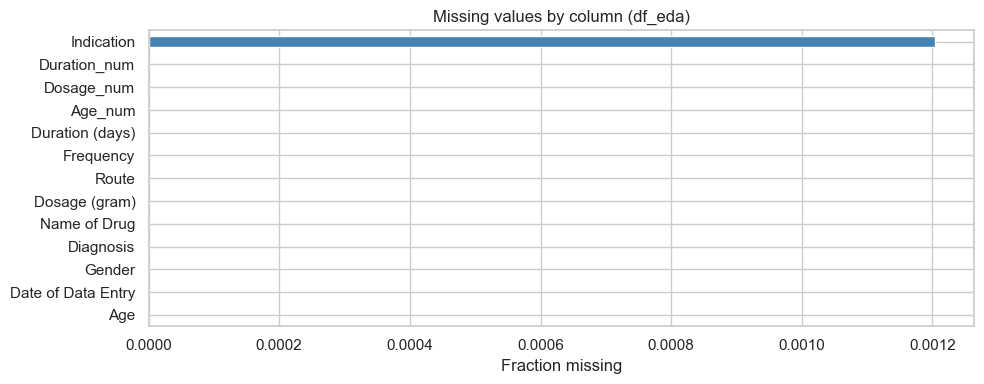

In [34]:
# Missingness bar (all columns; mostly zero after numeric filter)
m = df_eda.isna().mean().sort_values(ascending=True)
plt.figure(figsize=(10, max(4, len(m) * 0.2)))
m.plot(kind='barh', color='steelblue')
plt.xlabel('Fraction missing')
plt.title('Missing values by column (df_eda)')
plt.tight_layout()
plt.show()

,column,iqr_low,iqr_high,n_outside,pct_outside
0,Age_num,-2.50,105.50,0,0.00
1,Dosage_num,-0.25,1.75,31,3.73
2,Duration_num,-5.00,11.00,19,2.29


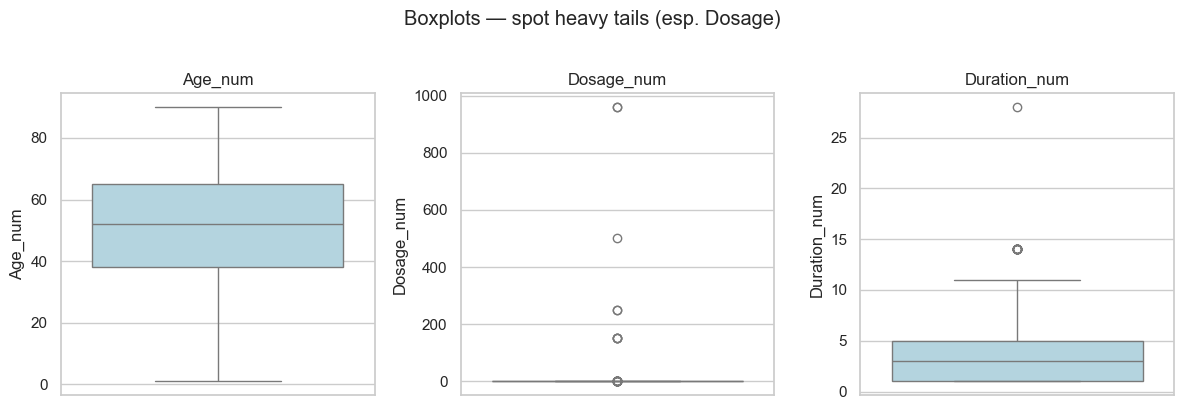

In [35]:
# IQR flags (exploratory; DU reports — does not drop absent a domain rule)


def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

num_cols = ['Age_num', 'Dosage_num', 'Duration_num']
rows = []
for col in num_cols:
    lo, hi = iqr_bounds(df_eda[col])
    mask = (df_eda[col] < lo) | (df_eda[col] > hi)
    rows.append({'column': col, 'iqr_low': lo, 'iqr_high': hi, 'n_outside': int(mask.sum()), 'pct_outside': round(100 * mask.mean(), 2)})
out_tbl = pd.DataFrame(rows)
display(out_tbl)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df_eda[col], ax=ax, color='lightblue')
    ax.set_title(col)
plt.suptitle('Boxplots — spot heavy tails (esp. Dosage)', y=1.02)
plt.tight_layout()
plt.show()

In [36]:
skew_row = df_eda[num_cols].skew(numeric_only=True).rename('skewness')
print('Skewness (>|1| suggests strong asymmetry):')
display(skew_row.to_frame().T)

Skewness (>|1| suggests strong asymmetry):


,Age_num,Dosage_num,Duration_num
skewness,-0.180782,15.895163,1.698015


### Data quality action log

| Check | Finding (fill from outputs above) | Deferred to Preparation / Modeling |
|-------|-------------------------------------|------------------------------------|
| Repeated CSV headers | Removed via `get_junk_mask` | — |
| Duplicate rows | Count in §4 | If any: dedupe rule |
| Missing values | Bar chart + table | Imputation / drop / indicator |
| IQR outliers | Rates for Age / Dosage / Duration | Winsorize / robust model / sensitivity (supervisors: **no blind statistical drop** in thesis without domain rule) |
| Skewed dosage | Inspect max vs median | Log1p / robust scaling in prep |
| Date cohorts | §7 | Time-based split vs random (see synthesis) |

## 5. Regression-oriented: correlation & density plots

**Pearson** correlation only captures **linear** trends. With **heavily skewed dose** (skew much greater than 1), *r* near 0 vs duration is common even when a **non-linear** or **noisy** relationship exists.

**Hexbin** plots count overlapping points — important because **duration is discrete** (many rows share the same day count), so a plain scatter can look misleadingly "empty".

**Spearman** (rank) correlation captures **monotonic** association and is often more informative than Pearson when variables are skewed or ordinal-ranked. **Subgroup** correlations (e.g. by Route) need **large enough n** per slice — treat small groups as exploratory only.


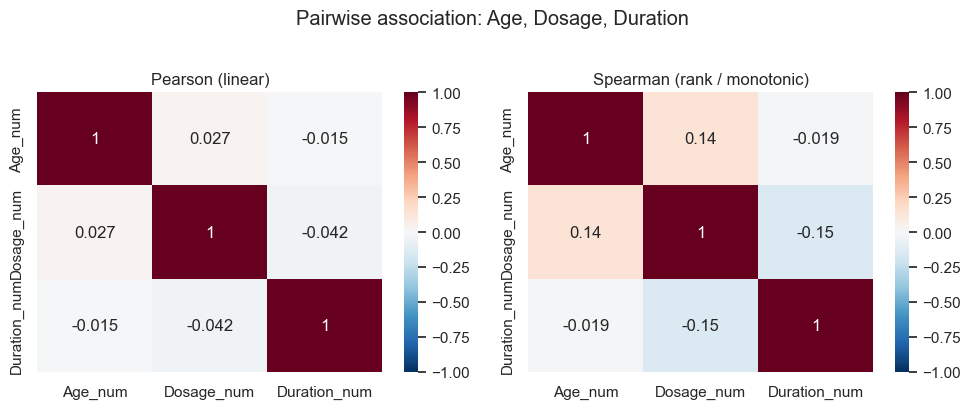

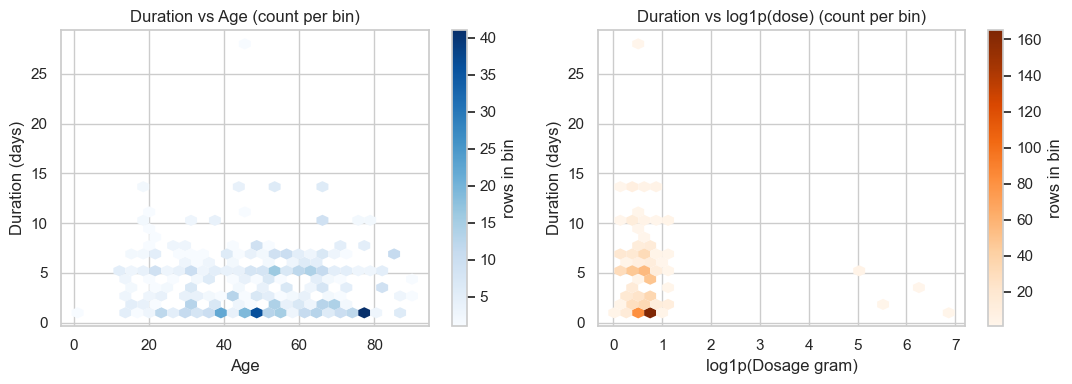

In [37]:
pearson = df_eda[num_cols].corr()
spearman = df_eda[num_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(pearson, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson (linear)')
sns.heatmap(spearman, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman (rank / monotonic)')
plt.suptitle('Pairwise association: Age, Dosage, Duration', y=1.02)
plt.tight_layout()
plt.show()

# Hexbin: discrete Duration stacks many points on same pixel — plain scatter can look "empty"
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
hb0 = axes[0].hexbin(df_eda['Age_num'], df_eda['Duration_num'], gridsize=28, cmap='Blues', mincnt=1, linewidths=0)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Duration (days)')
axes[0].set_title('Duration vs Age (count per bin)')
plt.colorbar(hb0, ax=axes[0], label='rows in bin')

xd = np.log1p(df_eda['Dosage_num'])
hb1 = axes[1].hexbin(xd, df_eda['Duration_num'], gridsize=28, cmap='Oranges', mincnt=1, linewidths=0)
axes[1].set_xlabel('log1p(Dosage gram)')
axes[1].set_ylabel('Duration (days)')
axes[1].set_title('Duration vs log1p(dose) (count per bin)')
plt.colorbar(hb1, ax=axes[1], label='rows in bin')
plt.tight_layout()
plt.show()


## 6. Univariate distributions (target & key numerics)

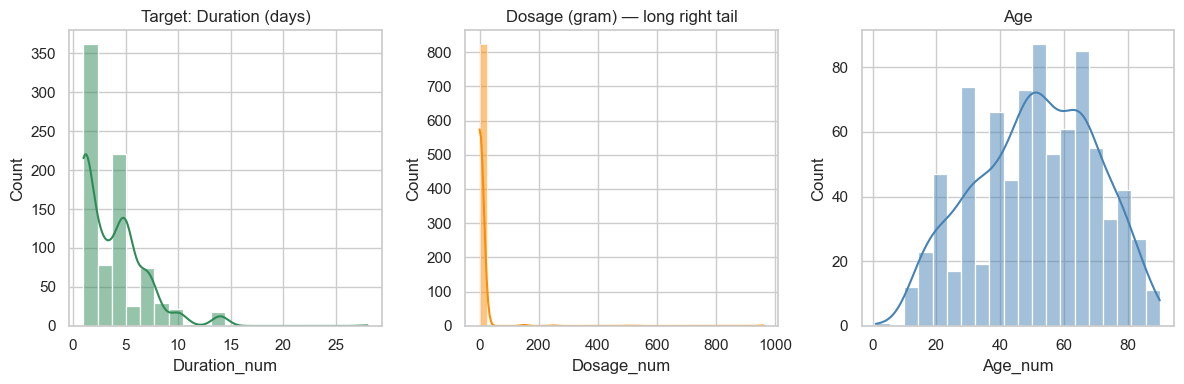

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.histplot(df_eda['Duration_num'], bins=20, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Target: Duration (days)')
sns.histplot(df_eda['Dosage_num'], bins=40, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Dosage (gram) — long right tail')
sns.histplot(df_eda['Age_num'], bins=20, kde=True, ax=axes[2], color='steelblue')
axes[2].set_title('Age')
plt.tight_layout()
plt.show()

## 7. Date of entry & cohort reminder

Parse **Date of Data Entry** for exploratory trends (optional plot). **Supervisor note:** random train/test shuffles calendar time; for deployment-realistic evaluation, a **chronological** split is often stronger — document intent for Phase 3/4.

In [39]:
# Parse when possible (day-first strings in sample)
dt = pd.to_datetime(df_eda['Date of Data Entry'], dayfirst=True, errors='coerce')
parse_ok = dt.notna().mean()
print(f'Date parsed OK: {parse_ok:.1%} of df_eda rows')
if dt.notna().any():
    df_tmp = df_eda.assign(entry_date=dt).dropna(subset=['entry_date'])
    df_tmp['year_month'] = df_tmp['entry_date'].dt.to_period('M').astype(str)
    monthly = df_tmp.groupby('year_month').agg(mean_dur=('Duration_num', 'mean'), n=('Duration_num', 'count'))
    if len(monthly) > 1:
        plt.figure(figsize=(10, 4))
        plt.plot(monthly.index, monthly['mean_dur'], marker='o')
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Mean duration (days)')
        plt.title('Mean duration by month (exploratory — cohort shift check)')
        plt.tight_layout()
        plt.show()

Date parsed OK: 100.0% of df_eda rows


## 8. High-cardinality & categorical fields

For regression, one-hot on **Drug / Diagnosis / Indication** explodes dimensionality; Preparation should choose **grouping rare levels**, **hashing**, or **target encoding with CV** (leakage risk if done naïvely). DU documents counts and sparsity.

In [40]:
cat_profile = []
for col in ['Gender', 'Route', 'Frequency', 'Name of Drug', 'Diagnosis', 'Indication']:
    if col in df_eda.columns:
        vc = df_eda[col].astype(str).str.strip().replace({'nan': np.nan})
        nunique = vc.nunique(dropna=True)
        miss = vc.isna().mean()
        cat_profile.append({'column': col, 'n_unique': int(nunique), 'frac_missing': round(miss, 4)})
cap = pd.DataFrame(cat_profile).sort_values('n_unique', ascending=False)
display(cap)

for col in ['Gender', 'Route', 'Frequency']:
    if col in df_eda.columns:
        print(f'\n--- {col} (top 8) ---')
        print(df_eda[col].astype(str).value_counts().head(8))

,column,n_unique,frac_missing
4,Diagnosis,263,0.0000
5,Indication,220,0.0012
3,Name of Drug,55,0.0000
2,Frequency,4,0.0000
1,Route,3,0.0000
0,Gender,2,0.0000



--- Gender (top 8) ---
Gender
Male      449
Female    382
Name: count, dtype: int64

--- Route (top 8) ---
Route
IV      534
Oral    293
IM        4
Name: count, dtype: int64

--- Frequency (top 8) ---
Frequency
BD     430
TDS    283
OD     110
QID      8
Name: count, dtype: int64


## 9. Target vs key categories

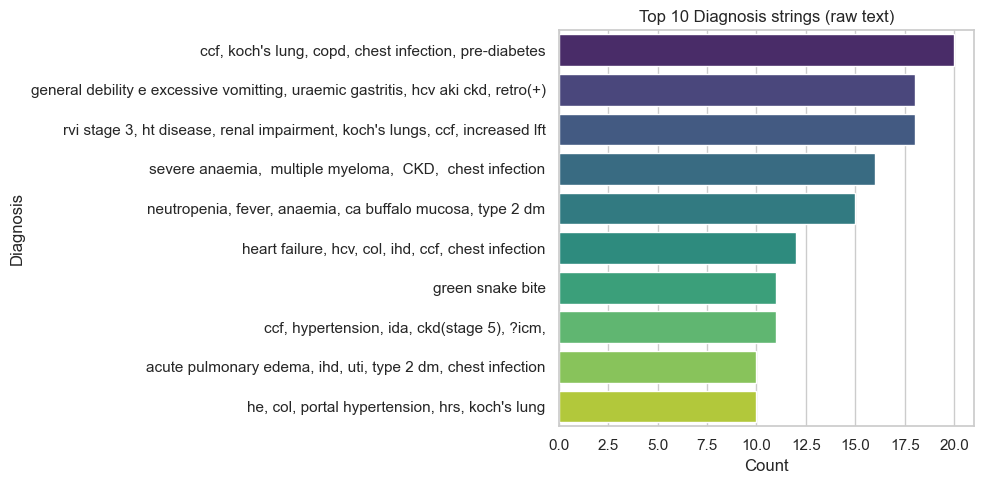

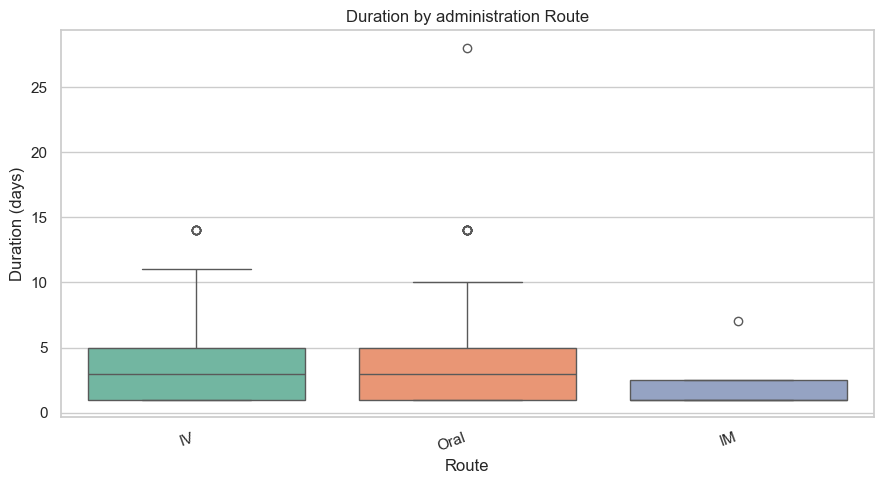

In [41]:
top_diag = df_eda['Diagnosis'].astype(str).value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(y=top_diag.index, x=top_diag.values, palette='viridis')
plt.title('Top 10 Diagnosis strings (raw text)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_eda, x='Route', y='Duration_num', palette='Set2')
plt.title('Duration by administration Route')
plt.ylabel('Duration (days)')
plt.xlabel('Route')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 10. Five-supervisor synthesis (Data Understanding)

**What must be covered before regression:** missing patterns; duplicate / junk rows; IQR and domain-plausible extremes; skew (Duration, **Dosage** tail); pairwise associations / multicollinearity risk; **cardinality** of Drug/Diagnosis/Indication; **leakage** (does any text encode duration or post-hoc pathway?); **temporal** structure of `Date of Data Entry`.

**Copy discipline:** `df_raw` immutable; one working `df_du`; analysis slice `df_eda` — avoid `df2`/`df3` chains.

**Outliers (DU vs Preparation):** supervisors recommend **quantify + visualize** in DU; **do not** drop purely on IQR without clinical/admin rule; Preparation may use robust methods, **winsorization with stated bounds**, or sensitivity analysis.

**High-cardinality text:** document unique counts & long tail; next phase needs **rare-level bucketing**, **hashing**, or **cross-fitted target encoding** — never fit target statistics on full data before split.

**Dates:** beware **cohort shift**; consider **time-ordered** train/validation/test for generalization story.

---

### Checklist — hand off to Data Preparation

- [ ] Finalize missing-value policy per column (core numerics already complete in `df_eda`).
- [ ] Text normalization (case, typos) vs keep raw + rare bucket.
- [ ] Encode categoricals (Cardinality table above).
- [ ] Target / feature transforms (`log1p(Dosage)`, etc.) with train-only fit.
- [ ] Train-test split: random **vs** chronological — justify for thesis.
- [ ] Document schema + `random_state` + exports (align with `02b_DataPreparation_Hospital.ipynb`).

In [42]:
# optional: list columns for Modeling phase
print('Columns available:', list(df_eda.columns))

Columns available: ['Age', 'Date of Data Entry', 'Gender', 'Diagnosis', 'Name of Drug', 'Dosage (gram)', 'Route', 'Frequency', 'Duration (days)', 'Indication', 'Age_num', 'Dosage_num', 'Duration_num']
